In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import datasets, transforms

In [2]:
import time

Classes :

In [3]:
class Dataset:
    
    def __init__(self, conf, test_bool):
        self.conf = conf
        self.test_bool = test_bool
        self.data_loader = None

    def preprocess(self):
        transforms_list = []
        transforms_list += self.create_transforms(self.conf["data_transforms"])
        if (self.test_bool == False) :
            transforms_list += self.create_transforms(self.conf["train_data_transforms"])
            self.data_loader = self.load(transforms_list, True)
        else :
            transforms_list += self.create_transforms(self.conf["test_data_transforms"])
            self.data_loader = self.load(transforms_list, False)

    def create_transforms(self, data_transforms):
        transforms_list = []
        for trans in data_transforms:
            if trans["type"] == "elastic":
                transforms_list.append(transforms.ElasticTransform())
                print("Elastic transformation applied.")
            if trans["type"] == "rotation":
                transforms_list.append(transforms.RandomRotation(trans["degree"]))
                print("Rotation transformation applied.")
            if trans["type"] == "pad":
                transforms_list.append(transforms.Pad(trans["padding"]))
                print("Padding transformation applied.")
            if trans["type"] == "resize":
                transforms_list.append(transforms.Resize(trans["size"]))
                print("Resize transformation applied.")
        return transforms_list
        

    def load(self, transforms_list, train_bool):

        transforms_list.append(transforms.ToTensor())
               
        if self.conf["normalization"] == True:
            transforms_list.append(transforms.Normalize((0.1307,), (0.3081,)))
        
        transform = transforms.Compose(transforms_list)

        dataset = datasets.MNIST(root='./data', train=train_bool, download=True, transform=transform)
        g = torch.Generator()
        g.manual_seed(self.conf["seed"])
        return DataLoader(dataset, batch_size=self.conf["batch_size"], shuffle=train_bool, generator=g)
    

    def display(self):
        _, axes = plt.subplots(1, 10, figsize=(18, 2))
        for i in range(10):
            image, label = self.data_loader.dataset[i]
            axes[i].imshow(image.squeeze(), cmap='gray')
            axes[i].set_title(f'Label: {label}')
        plt.show()

In [4]:
class Net(nn.Module):
    def __init__(self, conf):
        super(Net, self).__init__()
        self.conf = conf
        self.net = nn.ModuleList()
        
        layers = self.conf["layers"]

        for layer in layers:
            if layer["type"] == "conv2d":
                dilation = 1
                padding = 0
                if (layer.get("dilation") != None):
                    dilation = layer["dilation"]
                if (layer.get("padding") != None):
                    padding = layer["padding"]
                self.net.append(nn.Conv2d(layer["input_channels"], layer["output_channels"], layer["kernel_size"], dilation=dilation, padding=padding).to(self.conf["device"]))

            elif layer["type"] == "fc":
                self.net.append(nn.Linear(layer["input_channels"], layer["output_channels"]).to(self.conf["device"]))
            
            elif layer["type"] == "dropout":
                self.net.append(nn.Dropout(layer["p"])).to(self.conf["device"])

    def forward(self, x):
        layers = self.conf["layers"]
        i = 0
        for layer in layers:
            if layer["type"] == "conv2d":
                x = self.net[i](x)
                i = i + 1
            
            elif layer["type"] == "avg_pool2d":
                x = F.avg_pool2d(x, (2, 2))

            elif layer["type"] == "max_pool2d":
                x = F.max_pool2d(x, (2, 2))
            
            elif layer["type"] == "fc":
                # si x contient des images (n'est pas un vecteur)
                if len(x.shape) > 2:
                    x = x.view(-1, layer["input_channels"])
                x = self.net[i](x)
                i = i + 1

            elif layer["type"] == "dropout":
                x = self.net[i](x)
                i = i + 1

            # activation function (optional)
            act = layer.get("activation")
            if act == "tanh":
                x = torch.tanh(x)
            elif act == "relu":
                x = F.relu(x)
            elif act == "softmax":
                x = F.softmax(x, dim=1)

        return x

    def display(self):
        print(self)
        return


In [5]:
class Executer:

    def __init__(self, net, train_dataset, test_dataset, conf):
        
        self.conf = conf
        self.net = net.to(conf["device"])
        self.train_dataset = train_dataset
        self.test_dataset = test_dataset
        self.accuracy = None


    def create_criterion_optimizer(self):
        criterion = None
        optimizer = None
        if self.conf["loss_function"]["type"] == "cross_entropy":
            criterion = nn.CrossEntropyLoss()

        if self.conf["optimizer"]["type"] == "sgd":
            optimizer = optim.SGD(self.net.parameters(), lr=self.conf["optimizer"]["lr"], momentum=self.conf["optimizer"]["momentum"])

        if self.conf["optimizer"]["type"] == "adam":
            optimizer = optim.Adam(self.net.parameters(), lr=self.conf["optimizer"]["lr"])

        return criterion, optimizer
    

    def train(self):

        # initialisation des paramètres d'apprentissage
        criterion, optimizer = self.create_criterion_optimizer()
        
        total = 0
        best_eval_loss = float("inf")
        patience_counter = 0
        num_epochs = self.conf["num_epochs"]
        # loop over the dataset multiple times
        for epoch in range(num_epochs):

            self.net.train()

            train_loss = 0.0

            # pour chaque batch
            for i, (inputs, labels) in enumerate(self.train_dataset.data_loader):
                # get the inputs
                inputs, labels = inputs.to(self.conf["device"]), labels.to(self.conf["device"])

                optimizer.zero_grad()
                outputs = self.net(inputs)
                loss = criterion(outputs, labels)
                # calcul des gradients
                loss.backward()
                # ajustement des poids en fonction des gradients
                optimizer.step()

                train_loss += loss.item() * inputs.size(0)
                total += labels.size(0)

                if i % 500 == 0 :
                    print("[%d, %5d] loss: %.3f" % (epoch + 1, i + 1, loss.item()))

            train_loss /= len(self.train_dataset.data_loader.dataset)

            # ====== EARLY STOPPING ======
            if (self.conf["early_stopping"]):
                eval_loss,_,_,_ = self.evaluate()
                print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Eval Loss: {eval_loss:.4f}")
                
                delta = 10**(-4)
                if eval_loss < best_eval_loss - delta :
                    best_eval_loss = eval_loss
                    patience_counter = 0

                    # sauvegarde du meilleur modèle
                    #torch.save(model.state_dict(), "best_model.pt")
                else:
                    patience_counter += 1

                if patience_counter >= self.conf["patience"]:
                    print("Early stopping déclenché.")
                    print("Arrêt à [%d, %5d] loss: %3f" % (epoch + 1, i + 1, loss.item()))
                    break

        # recharger le meilleur modèle
        #model.load_state_dict(torch.load("best_model.pt"))
        print(f"Finished Training on {total} samples")


    def evaluate(self):

        # ensure model in evaluation mode (disables Dropout, sets BatchNorm to eval)
        self.net.eval()

        criterion, _ = self.create_criterion_optimizer()

        correct = 0
        total = 0
        y_true = []
        y_pred = []
        eval_loss = 0.0

        with torch.no_grad():
            for inputs, labels in self.test_dataset.data_loader:
                inputs, labels = inputs.to(self.conf["device"]), labels.to(self.conf["device"])

                outputs = self.net(inputs)
                loss = criterion(outputs, labels)
                _, predicted = torch.max(outputs, 1)

                eval_loss += loss.item() * inputs.size(0)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                y_true.extend(labels.cpu().numpy())
                y_pred.extend(predicted.cpu().numpy())

        eval_loss /= len(self.test_dataset.data_loader.dataset)
        accuracy = 100 * correct / total
        self.accuracy = accuracy
        print(f"Finished Evaluating on {total} samples")
        return eval_loss, accuracy, y_true, y_pred
        

    def evaluate_time(self):

        # ensure model in evaluation mode (disables Dropout, sets BatchNorm to eval)
        self.net.eval()
        
        total = 0
        correct = 0

        # accumulate separate timings
        total_load_time = 0.0
        total_forward_time = 0.0

        data_iter = iter(self.test_dataset.data_loader)
        
        # désactivation du calcul des gradients
        
        with torch.no_grad():
            while True:
                # --- DATA LOADING ---
                load_start = time.perf_counter()
                try:
                    images, labels = next(data_iter)
                except StopIteration:
                    break
                images = images.to(self.conf["device"])
                labels = labels.to(self.conf["device"])
                load_end = time.perf_counter()

                total_load_time += (load_end - load_start)

                # --- FORWARD ---
                forward_start = time.perf_counter()
                outputs = self.net(images)
                forward_end = time.perf_counter()

                total_forward_time += (forward_end - forward_start)

                total += labels.size(0)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        self.accuracy = accuracy
        print(f"Finished Testing on {total} samples")
        return total_forward_time, total_load_time

    
    def display(self):
        print(self.accuracy)
        _,_,y_true, y_pred = self.evaluate()
        if "confusion_matrix" in self.conf["display"]:
            self.plot_matrix(y_true, y_pred)


    def plot_matrix(self, y_true, y_pred):
        classes = self.test_dataset.data_loader.dataset.classes
        cm = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0','1','2','3','4','5','6','7','8','9'])
        disp.plot(cmap=plt.cm.Blues)
        plt.title('Confusion Matrix', fontsize=15, pad=20)
        plt.xlabel('Prediction', fontsize=11)
        plt.ylabel('Actual', fontsize=11)
        plt.gca().xaxis.set_label_position('top')
        plt.gca().xaxis.tick_top()
        plt.gca().figure.subplots_adjust(bottom=0.2)
        plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)




In [6]:
class Experiment:

    def __init__(self, conf):
        self.conf = conf
        self.train_dataset = None
        self.test_dataset = None
        self.net = None
        self.executer = None


    def set_global_seed(self):
        torch.manual_seed(self.conf["seed"])


    def prepare_train_data(self):
        self.train_dataset = Dataset(self.conf, test_bool = False)
        self.train_dataset.preprocess()


    def build_network(self):
        self.set_global_seed()
        self.net = Net(self.conf)


    def build_network_time(self):
        before_network = time.perf_counter()
        self.build_network()
        after_network = time.perf_counter()
        return after_network - before_network


    def train(self):
        self.executer = Executer(self.net, self.train_dataset, self.test_dataset, self.conf)
        self.executer.train()


    def prepare_test_data(self):
        self.test_dataset = Dataset(self.conf, test_bool = True)
        self.test_dataset.preprocess()


    def prepare_test_data_time(self):
        before_test_data = time.perf_counter()
        self.prepare_test_data()
        after_test_data = time.perf_counter()
        return after_test_data - before_test_data


    def test(self):
        self.executer = Executer(self.net, self.train_dataset, self.test_dataset, self.conf)
        return self.executer.evaluate()


    def test_time(self):
        self.executer = Executer(self.net, self.train_dataset, self.test_dataset, self.conf)
        return self.executer.evaluate_time()
    

    def display_train_data(self):
        self.train_dataset.display()
    

    def display_network(self):
        self.net.display()


    def display_test_data(self):
        self.test_dataset.display()


    def display_test(self):
        self.executer.display()


In [7]:
device = torch.device('cpu')  # Force l'utilisation du CPU

In [8]:
conf = {
    # device configuration
    "device": device,

    # seed configuration (for data shuffle and weights initialisation)
    "seed": 42,
    
    # data configuration
    "dataset": "mnist",
    "normalization": True,
    "data_transforms": [],

    # net configuration
    "layers": [
        {"type": "fc", "input_channels": 28*28, "output_channels": 400, "activation": "relu"},
        {"type": "fc", "input_channels": 400, "output_channels": 300, "activation": "relu"},
        {"type": "fc", "input_channels": 300, "output_channels": 10}
    ],
    
    # train configuration
    "train_data_transforms": [],
    "loss_function": {"type": "cross_entropy"},
    "optimizer": {"type": "sgd", "lr": 0.005, "momentum": 0.9},
    "num_epochs": 2,
    "batch_size": 32,
    "early_stopping": True,
    "patience": 3,
    
    # test configuration
    "test_data_transforms": [],
    "display": ["confusion_matrix"]
}

In [9]:
experiment = Experiment(conf)

In [10]:
experiment.set_global_seed()

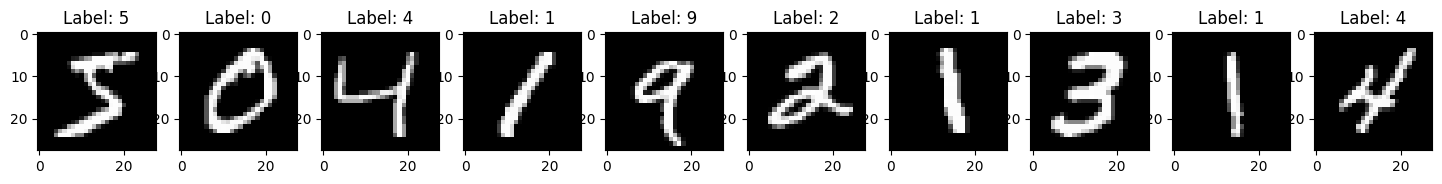

In [11]:
experiment.prepare_train_data()
experiment.display_train_data()

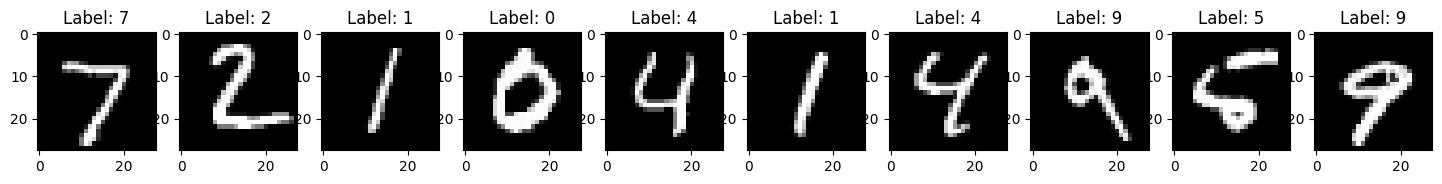

In [12]:
test_data_time = experiment.prepare_test_data_time()
experiment.display_test_data()

In [13]:
network_time = experiment.build_network_time()
experiment.display_network()

Net(
  (net): ModuleList(
    (0): Linear(in_features=784, out_features=400, bias=True)
    (1): Linear(in_features=400, out_features=300, bias=True)
    (2): Linear(in_features=300, out_features=10, bias=True)
  )
)


In [14]:
experiment.train()

[1,     1] loss: 2.309
[1,   501] loss: 0.111
[1,  1001] loss: 0.253
[1,  1501] loss: 0.042
Finished Evaluating on 10000 samples
Epoch 1/2 | Train Loss: 0.2857 | Eval Loss: 0.1265
[2,     1] loss: 0.032
[2,   501] loss: 0.041
[2,  1001] loss: 0.317
[2,  1501] loss: 0.027
Finished Evaluating on 10000 samples
Epoch 2/2 | Train Loss: 0.1005 | Eval Loss: 0.0833
Finished Training on 120000 samples


Finished Testing on 10000 samples
97.23
Finished Evaluating on 10000 samples


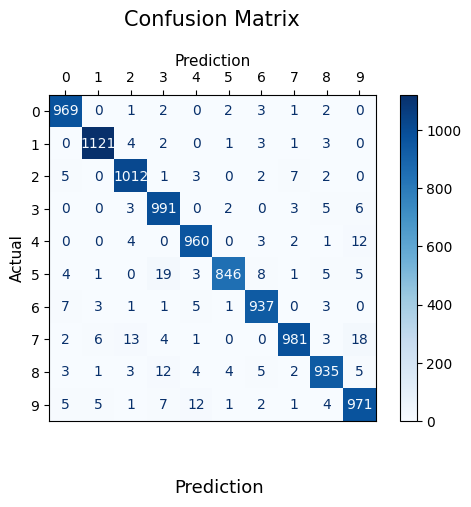

In [ ]:
test_time = experiment.test_time()
experiment.display_test()